<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Parsons_Political_System_Experiment_V2_1_REAL_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Вычислительная модель политической системы Толкотта Парсонса
## V2.1 — реальная международная панель, единый progress bar

**Страны:** USA, DEU, CHN, IND, BRA, ZAF, JPN, TUR, RUS, KAZ.  
**Основное окно:** 2000–2024 гг.  
**Минимальное покрытие индикатора:** 70%.  
**Сценарный дизайн:** 24 класса strain × 15 реакций × 10 сидов × 10 стран.

Ноутбук работает только с зафиксированными файлами `Parsons_real_panel_long.csv` или `Parsons_real_dataset.xlsx`. Сетевой сбор данных и синтетическая подмена отсутствуют.

Все математические конструкции являются вычислительной операционализацией понятий Парсонса, а не приписываемыми ему готовыми формулами.

## 0. Выходы эксперимента

После выполнения создаются четыре Excel-книги с листами `README` и навигацией:

1. `00_Parsons_Master_Index.xlsx`;
2. `01_Parsons_Data_and_Measurement.xlsx`;
3. `02_Parsons_Historical_and_Simulation.xlsx`;
4. `03_Parsons_Statistics_and_Figures.xlsx`.

Дополнительно сохраняются PNG, SVG, CSV.GZ, `manifest.json`, `README.md` и единый ZIP-архив. Исполненный `.ipynb` можно сохранить из Colab и разместить на GitHub.

In [1]:
#@title 0.1. Установка зависимостей
!pip -q install pandas numpy scipy scikit-learn statsmodels matplotlib xlsxwriter tqdm nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.1 MB/s eta 0:00:00


In [2]:
#@title 0.2. Импорты и фиксированная конфигурация
from __future__ import annotations

import json
import hashlib
import random
import shutil
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy import stats
from scipy.special import expit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names.*',
    category=UserWarning,
)
warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

@dataclass(frozen=True)
class ExperimentConfig:
    countries: Tuple[str, ...] = (
        'USA','DEU','CHN','IND','BRA','ZAF','JPN','TUR','RUS','KAZ'
    )
    start_year: int = 2000
    end_year: int = 2024
    coverage_threshold: float = 0.70
    train_end: int = 2017
    validation_end: int = 2021
    test_start: int = 2022
    n_seeds: int = 10
    horizon: int = 10
    equilibrium_window: int = 3
    breakdown_window: int = 2
    ridge_alpha: float = 2.0
    shock_scale: float = 0.20
    reaction_scale: float = 0.10
    noise_scale: float = 0.010
    random_seed: int = 20260803
    output_dir: str = '/content/parsons_v2_1_outputs'

CFG = ExperimentConfig()
OUT = Path(CFG.output_dir)
for folder in ('figures_png','figures_svg','tables_csv','logs'):
    (OUT/folder).mkdir(parents=True, exist_ok=True)

random.seed(CFG.random_seed)
np.random.seed(CFG.random_seed)

print('Конфигурация зафиксирована:', CFG.start_year, CFG.end_year, CFG.coverage_threshold)

Конфигурация зафиксирована: 2000 2024 0.7


## 1. Онтология и основные формулы

Состояние системы:

\[
\mathbf X_{c,t}=[A_{c,t},G_{c,t},I_{c,t},L_{c,t}]^{\top}.
\]

Функциональное равновесие:

\[
FE_{c,t}=(A_{c,t}G_{c,t}I_{c,t}L_{c,t})^{1/4}.
\]

Слабейшее функциональное звено:

\[
B_{c,t}=\min(A_{c,t},G_{c,t},I_{c,t},L_{c,t}).
\]

Несогласованность функций:

\[
D_{c,t}=\sqrt{\frac{1}{4}\sum_f(f_{c,t}-\bar f_{c,t})^2}.
\]

Вычислительный strain:

\[
S_{c,t}=0.45D_{c,t}+0.30\Delta_{c,t}+0.25(1-Inst_{c,t}).
\]

In [3]:
#@title 1.1. Онтология в коде
AGIL = ('A','G','I','L')

STRAIN_CLASSES = (
    'adaptive_insufficiency','adaptive_allocation_strain',
    'goal_definition_strain','goal_priority_strain',
    'goal_attainment_strain','mobilization_strain',
    'integrative_coordination_strain','membership_strain',
    'solidarity_strain','pattern_maintenance_strain',
    'motivational_strain','socialization_strain',
    'normative_expectation_strain','legitimation_strain',
    'role_strain','role_conflict_strain','authority_strain',
    'sanction_strain','money_medium_strain','power_medium_strain',
    'influence_medium_strain','value_commitment_strain',
    'interchange_strain','boundary_strain',
)

REACTIONS = (
    'resolution','arrestation','isolation','structural_change',
    'differentiation','adaptive_upgrading','inclusion',
    'value_generalization','institutionalization','legitimation',
    'socialization','social_control','allocation','mobilization',
    're_specification_of_goals',
)

assert len(STRAIN_CLASSES)==24 and len(REACTIONS)==15
ONTOLOGY_HASH = hashlib.sha256(
    '|'.join(AGIL+STRAIN_CLASSES+REACTIONS).encode('utf-8')
).hexdigest()
print('Ontology SHA-256:', ONTOLOGY_HASH)

Ontology SHA-256: 2587d9a172a071f7d9c208339e832a6c94a9eb9251aede45db69614b3f897019


## 2. Единый progress bar

Progress bar создаётся **один раз** в этой ячейке и не закрывается до завершения экспорта. Другие `tqdm` в ноутбуке не используются.

Объём сценарного блока:

\[
10\times24\times15\times10=36\,000.
\]

Подготовительные и экспортные этапы добавляются к тому же счётчику.

In [4]:
#@title 2.1. Единственный диспетчер прогресса
SIMULATION_UNITS = (
    len(CFG.countries)*len(STRAIN_CLASSES)*len(REACTIONS)*CFG.n_seeds
)
STAGE_UNITS = 13
GLOBAL_PROGRESS = tqdm(
    total=SIMULATION_UNITS+STAGE_UNITS,
    desc='Parsons V2.1',
    unit='unit',
    dynamic_ncols=True,
    leave=True,
)

PIPELINE_LOG=[]

def advance(stage: str, units: int=1) -> None:
    PIPELINE_LOG.append({'stage':stage,'units':units})
    GLOBAL_PROGRESS.set_postfix_str(stage[:90], refresh=False)
    GLOBAL_PROGRESS.update(units)

Parsons V2.1:   0%|          | 0/36013 [00:00<?, ?unit/s]

## 3. Загрузка и аудит данных

Метаданные `AGIL`, `direction`, `variable_name` читаются прямо из реальной панели. Старый программный словарь индикаторов не используется, поэтому конфликты `direction_x/direction_y` исключены.

In [5]:
#@title 3.1. Поиск файла и проверка схемы
REQUIRED_COLUMNS={
    'country','year','indicator_code','indicator_name','value',
    'AGIL','variable_name','direction'
}

def locate_input() -> Path:
    candidates=[
        Path('/content/Parsons_real_panel_long.csv'),
        Path('/content/Parsons_real_dataset.xlsx'),
        Path('./Parsons_real_panel_long.csv'),
        Path('./Parsons_real_dataset.xlsx'),
        Path('/mnt/data/Parsons_real_panel_long.csv'),
        Path('/mnt/data/Parsons_real_dataset.xlsx'),
    ]
    for p in candidates:
        if p.exists():
            return p
    try:
        from google.colab import files
        print('Загрузите Parsons_real_panel_long.csv или Parsons_real_dataset.xlsx')
        uploaded=files.upload()
        if not uploaded:
            raise FileNotFoundError('Файл не загружен.')
        return Path(next(iter(uploaded)))
    except ImportError as exc:
        raise FileNotFoundError('Реальная панель не найдена.') from exc

DATA_PATH=locate_input()
raw_all=(
    pd.read_csv(DATA_PATH)
    if DATA_PATH.suffix.lower()=='.csv'
    else pd.read_excel(DATA_PATH, sheet_name='Panel_Long')
)
missing=REQUIRED_COLUMNS-set(raw_all.columns)
if missing:
    raise ValueError(f'Отсутствуют обязательные столбцы: {sorted(missing)}')

raw_all['year']=pd.to_numeric(raw_all['year'],errors='raise').astype(int)
raw_all['value']=pd.to_numeric(raw_all['value'],errors='coerce')
raw_all['direction']=pd.to_numeric(raw_all['direction'],errors='raise').astype(int)
raw_all['AGIL']=raw_all['AGIL'].astype(str).str.upper().str.strip()

DATA_HASH=hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
advance('данные загружены и проверены')
print(f'Файл: {DATA_PATH.name}; строк: {len(raw_all):,}; SHA-256: {DATA_HASH[:16]}...')

Файл: Parsons_real_panel_long.csv; строк: 6,760; SHA-256: 755d238060160602...


In [6]:
#@title 3.2. Фиксация окна 2000–2024
raw=raw_all[
    raw_all['country'].isin(CFG.countries)
    & raw_all['year'].between(CFG.start_year,CFG.end_year)
].copy()

duplicates=int(raw.duplicated(['country','year','indicator_code']).sum())
if duplicates:
    raise ValueError(f'Дубли country-year-indicator: {duplicates}')

missing_countries=set(CFG.countries)-set(raw['country'].unique())
if missing_countries:
    raise ValueError(f'Отсутствуют страны: {sorted(missing_countries)}')

data_quality=pd.DataFrame([{
    'first_year':int(raw.year.min()),'last_year':int(raw.year.max()),
    'countries':int(raw.country.nunique()),
    'indicators':int(raw.indicator_code.nunique()),
    'rows':int(len(raw)),'non_null_rate':float(raw.value.notna().mean()),
    'duplicates':duplicates,
}])
advance('окно 2000-2024 зафиксировано')
display(data_quality)

,first_year,last_year,countries,indicators,rows,non_null_rate,duplicates
0,2000,2024,10,26,6500,0.873077,0


## 4. Покрытие индикаторов

\[
C_i=\frac{\sum_{c,t}\mathbf 1(x_{c,t,i}\neq NaN)}{N_CN_T},
\qquad i\in model \Longleftrightarrow C_i\ge0.70.
\]

In [7]:
#@title 4.1. Фильтр покрытия ≥70 процентов
coverage=(
    raw.assign(observed=raw['value'].notna())
    .groupby(
        ['indicator_code','indicator_name','variable_name','AGIL','direction'],
        as_index=False,dropna=False,
    )
    .agg(observations=('observed','sum'),expected=('observed','size'))
)
coverage['coverage_rate']=coverage['observations']/coverage['expected']
coverage['included']=coverage['coverage_rate']>=CFG.coverage_threshold
coverage['decision']=np.where(
    coverage['included'],'included','excluded_below_70_percent'
)
included_codes=coverage.loc[coverage.included,'indicator_code'].tolist()
excluded_codes=coverage.loc[~coverage.included,'indicator_code'].tolist()
model_raw=raw[raw.indicator_code.isin(included_codes)].copy()

function_counts=(
    coverage[coverage.included].groupby('AGIL').size()
    .reindex(AGIL,fill_value=0).rename('included_indicators').reset_index()
)
if (function_counts.included_indicators==0).any():
    raise RuntimeError('После фильтра одна из функций AGIL осталась без индикаторов.')

advance('фильтр покрытия 70 процентов')
print(f'Включено индикаторов: {len(included_codes)}; исключено: {len(excluded_codes)}')
display(function_counts)

Включено индикаторов: 21; исключено: 5


,AGIL,included_indicators
0,A,7
1,G,6
2,I,5
3,L,3


## 5. Train-only предобработка

Train-интервал: 2000–2017 гг.

\[
z_{i,c,t}=\frac{x_{i,c,t}-Median_{train}(x_i)}{IQR_{train}(x_i)+\varepsilon},
\qquad \tilde x=\sigma(z).
\]

Для отрицательно направленного индикатора применяется отражение \(x^*=1-\tilde x\).

In [8]:
#@title 5.1. Импутация и нормализация без merge метаданных
EPS=1e-9
parts=[]
parameter_rows=[]

for indicator_code,g0 in model_raw.groupby('indicator_code',sort=True):
    g=g0.sort_values(['country','year']).copy()
    directions=g['direction'].dropna().unique()
    functions=g['AGIL'].dropna().unique()
    if len(directions)!=1 or len(functions)!=1:
        raise ValueError(
            f'{indicator_code}: direction={directions}, AGIL={functions}'
        )
    direction=int(directions[0])
    function=str(functions[0])

    train=g[g.year<=CFG.train_end]
    median=float(train.value.median())
    q1=float(train.value.quantile(.25)); q3=float(train.value.quantile(.75))
    iqr=q3-q1
    if not np.isfinite(median):
        raise RuntimeError(f'{indicator_code}: нет train-наблюдений')
    if not np.isfinite(iqr) or abs(iqr)<EPS:
        iqr=float(train.value.std())
    if not np.isfinite(iqr) or abs(iqr)<EPS:
        iqr=1.0

    country_medians=train.groupby('country').value.median().to_dict()
    g['value_observed']=g['value']
    g['imputed']=g['value'].isna()
    g['value_filled']=g.groupby('country',sort=False)['value'].ffill()
    mask=g.value_filled.isna()
    g.loc[mask,'value_filled']=g.loc[mask,'country'].map(country_medians)
    g['value_filled']=g.value_filled.fillna(median)
    g['z']=(g.value_filled-median)/(iqr+EPS)
    g['scaled']=expit(np.clip(g.z.to_numpy(),-8,8))
    if direction<0:
        g['scaled']=1.0-g['scaled']
    g['scaled']=g.scaled.clip(1e-4,1-1e-4)
    g['train_median']=median
    g['train_iqr']=iqr
    parts.append(g)
    parameter_rows.append({
        'indicator_code':indicator_code,
        'indicator_name':g.indicator_name.iloc[0],
        'variable_name':g.variable_name.iloc[0],
        'AGIL':function,'direction':direction,
        'train_median':median,'train_iqr':iqr,
        'train_non_null':int(train.value.notna().sum()),
    })

panel=pd.concat(parts,ignore_index=True)
train_parameters=pd.DataFrame(parameter_rows)
imputation_audit=(
    panel.groupby(['indicator_code','indicator_name','AGIL'],as_index=False)
    .agg(rows=('imputed','size'),observed_rows=('value_observed',lambda s:int(s.notna().sum())),imputed_rows=('imputed','sum'))
)
imputation_audit['imputation_rate']=imputation_audit.imputed_rows/imputation_audit.rows
assert panel.scaled.notna().all()
advance('train-only импутация и нормализация')
print('Предобработка завершена; максимальная доля импутации:', round(float(imputation_audit.imputation_rate.max()),3))

Предобработка завершена; максимальная доля импутации: 0.292


## 6. Индексы AGIL

\[
F_{f,c,t}=\frac{1}{|I_f|}\sum_{i\in I_f}x^*_{i,c,t},
\qquad
R_{f,c,t}=1-\frac{N_{imputed}}{N_{included}}.
\]

In [9]:
#@title 6.1. Состояния системы
agil_long=(
    panel.groupby(['country','year','AGIL'],as_index=False)
    .agg(score=('scaled','mean'),observed_share=('imputed',lambda s:1.0-float(s.mean())),n_indicators=('indicator_code','nunique'))
)
scores=agil_long.pivot(index=['country','year'],columns='AGIL',values='score').reset_index()
scores.columns.name=None
rel=(
    agil_long.pivot(index=['country','year'],columns='AGIL',values='observed_share')
    .reset_index().rename(columns={f:f'{f}_reliability' for f in AGIL})
)
rel.columns.name=None
state=scores.merge(rel,on=['country','year'],how='left').sort_values(['country','year']).reset_index(drop=True)

state['FE']=state[list(AGIL)].clip(lower=1e-9).prod(axis=1)**.25
state['Bottleneck']=state[list(AGIL)].min(axis=1)
state['Imbalance']=state[list(AGIL)].std(axis=1,ddof=0)
state['Reliability']=state[[f'{f}_reliability' for f in AGIL]].mean(axis=1)
for f in AGIL:
    state[f'd{f}']=state.groupby('country')[f].diff().fillna(0.0)
state['Delta']=np.sqrt(sum(np.square(state[f'd{f}']) for f in AGIL))
state['Institutionalization']=(.40*state.I+.35*state.L+.25*state.Reliability).clip(0,1)
state['Strain']=(.45*state.Imbalance+.30*state.Delta+.25*(1-state.Institutionalization)).clip(0,1)
advance('AGIL и системные индексы')
display(state.head(5))

,country,year,A,G,I,L,A_reliability,G_reliability,I_reliability,L_reliability,FE,Bottleneck,Imbalance,Reliability,dA,dG,dI,dL,Delta,Institutionalization,Strain
0,BRA,2000,0.374134,0.536019,0.413643,0.456382,1.0,0.833333,0.8,0.666667,0.441103,0.374134,0.060040,0.825000,0.000000,0.000000,0.000000,0.000000,0.000000,0.531441,0.144158
1,BRA,2001,0.373633,0.541273,0.399796,0.461549,1.0,0.500000,0.6,0.666667,0.439521,0.373633,0.064567,0.691667,-0.000501,0.005254,-0.013847,0.005167,0.015694,0.494377,0.160169
2,BRA,2002,0.389978,0.546532,0.400966,0.470829,1.0,0.833333,1.0,0.666667,0.447874,0.389978,0.062733,0.875000,0.016345,0.005259,0.001170,0.009280,0.019553,0.543926,0.148114
3,BRA,2003,0.374779,0.538231,0.388058,0.480057,1.0,0.833333,1.0,0.666667,0.440285,0.374779,0.067257,0.875000,-0.015199,-0.008300,-0.012907,0.009228,0.023488,0.541993,0.151814
4,BRA,2004,0.419143,0.526263,0.382403,0.491821,1.0,0.833333,1.0,0.666667,0.451308,0.382403,0.056988,0.875000,0.044364,-0.011968,-0.005656,0.011765,0.047768,0.543849,0.154013


In [10]:
#@title 6.2. Диагностика измерения
def cronbach_alpha(frame: pd.DataFrame) -> float:
    clean=frame.dropna(); k=clean.shape[1]
    if k<2 or len(clean)<3: return np.nan
    item_var=clean.var(axis=0,ddof=1).sum(); total_var=clean.sum(axis=1).var(ddof=1)
    return float(k/(k-1)*(1-item_var/total_var)) if total_var>0 else np.nan

rows=[]
for f in AGIL:
    block=panel[panel.AGIL==f].pivot_table(index=['country','year'],columns='variable_name',values='scaled',aggfunc='first')
    rows.append({'AGIL':f,'n_indicators':block.shape[1],'cronbach_alpha_diagnostic':cronbach_alpha(block),'mean_observed_share':float(agil_long.loc[agil_long.AGIL==f,'observed_share'].mean()),'note':'diagnostic only'})
measurement_diagnostics=pd.DataFrame(rows)
advance('диагностика измерения')
display(measurement_diagnostics)

,AGIL,n_indicators,cronbach_alpha_diagnostic,mean_observed_share,note
0,A,7,0.651750,1.0000,diagnostic only
1,G,6,0.301186,0.9380,diagnostic only
2,I,5,0.750425,0.8896,diagnostic only
3,L,3,0.821649,0.9040,diagnostic only


## 7. Историческая переходная модель

\[
\mathbf X_{c,t+1}=\mathbf B_c\mathbf Z_{c,t}+\mathbf b_c+\varepsilon_{c,t}.
\]

Сравнение: persistence baseline \(\widehat{\mathbf X}_{t+1}=\mathbf X_t\).

In [11]:
#@title 7.1. Ridge без предупреждений feature names
FEATURES=['A','G','I','L','FE','Bottleneck','Imbalance','Institutionalization','Strain','Reliability']
TARGETS=list(AGIL)
models:Dict[str,Ridge]={}
validation_rows=[]; transition_rows=[]

for country in CFG.countries:
    c=state[state.country==country].sort_values('year').reset_index(drop=True)
    X=c[FEATURES].iloc[:-1].copy()
    Y=c[TARGETS].iloc[1:].copy()
    years=c.year.iloc[1:].to_numpy()
    train_mask=years<=CFG.train_end
    val_mask=(years>CFG.train_end)&(years<=CFG.validation_end)
    test_mask=years>=CFG.test_start
    model=Ridge(alpha=CFG.ridge_alpha)
    model.fit(X.loc[train_mask],Y.loc[train_mask])
    models[country]=model
    transition_rows.append({'country':country,'n_train':int(train_mask.sum()),'intercept_json':json.dumps(model.intercept_.tolist()),'coefficients_json':json.dumps(model.coef_.tolist())})
    for split,mask in [('validation',val_mask),('test',test_mask)]:
        if not mask.any(): continue
        pred=np.clip(model.predict(X.loc[mask]),0,1)
        truth=Y.loc[mask].to_numpy()
        persistence=X.loc[mask,TARGETS].to_numpy()
        for j,f in enumerate(AGIL):
            mm=mean_squared_error(truth[:,j],pred[:,j]); pm=mean_squared_error(truth[:,j],persistence[:,j])
            validation_rows.append({'country':country,'split':split,'AGIL':f,'model_mse':mm,'persistence_mse':pm,'ratio_model_to_persistence':mm/pm if pm>0 else np.nan})

validation=pd.DataFrame(validation_rows)
transition_parameters=pd.DataFrame(transition_rows)
advance('историческая модель и OOS-проверка')
display(validation.groupby(['split','AGIL'])[['model_mse','persistence_mse','ratio_model_to_persistence']].mean().round(5))

model_mse  persistence_mse  ratio_model_to_persistence
split      AGIL                                                        
test       A       0.00295          0.00036                    44.37814
           G       0.00055          0.00012                     6.76666
           I       0.00119          0.00006                    47.19433
           L       0.01336          0.00018                   131.19248
validation A       0.00170          0.00220                     0.98353
           G       0.00046          0.00006                    18.50322
           I       0.00097          0.00014                    16.49215
           L       0.00880          0.00015                   119.79185

## 8. Пороги равновесия и breakdown

Пороги оцениваются только по train-периоду. Ячейка выводит одну компактную таблицу из четырёх строк.

In [12]:
#@title 8.1. Компактные train-only пороги
train_state=state[state.year<=CFG.train_end]
THRESHOLDS={
    'bottleneck':float(train_state.Bottleneck.quantile(.15)),
    'strain':float(train_state.Strain.quantile(.85)),
    'institutionalization':float(train_state.Institutionalization.quantile(.15)),
    'delta_stable':float(train_state.Delta.quantile(.60)),
}
thresholds=pd.DataFrame({'threshold':list(THRESHOLDS),'value':list(THRESHOLDS.values())})
advance('train-only пороги')
display(thresholds.round(4))

,threshold,value
0,bottleneck,0.3073
1,strain,0.1672
2,institutionalization,0.5300
3,delta_stable,0.0245


In [13]:
#@title 8.2. Каталоги strain и реакций
STRAIN_TARGETS={
'adaptive_insufficiency':(1,.2,.1,.1),'adaptive_allocation_strain':(.85,.35,.2,.1),'goal_definition_strain':(.15,1,.3,.2),'goal_priority_strain':(.2,.9,.45,.2),'goal_attainment_strain':(.25,1,.25,.15),'mobilization_strain':(.4,.9,.2,.15),'integrative_coordination_strain':(.2,.35,1,.25),'membership_strain':(.1,.2,1,.4),'solidarity_strain':(.1,.2,.95,.55),'pattern_maintenance_strain':(.1,.15,.35,1),'motivational_strain':(.15,.3,.35,.9),'socialization_strain':(.1,.15,.4,1),'normative_expectation_strain':(.1,.25,.85,.65),'legitimation_strain':(.1,.5,.7,.8),'role_strain':(.15,.3,.85,.55),'role_conflict_strain':(.15,.35,.95,.45),'authority_strain':(.15,.9,.55,.4),'sanction_strain':(.15,.45,.85,.35),'money_medium_strain':(1,.35,.1,.1),'power_medium_strain':(.2,1,.4,.25),'influence_medium_strain':(.1,.25,1,.5),'value_commitment_strain':(.1,.2,.45,1),'interchange_strain':(.65,.65,.65,.65),'boundary_strain':(.3,.45,.8,.55)}
REACTION_TARGETS={
'resolution':(.55,.55,.65,.55),'arrestation':(.45,.45,.55,.4),'isolation':(.3,.25,.75,.35),'structural_change':(.55,.55,.55,.55),'differentiation':(.55,.4,.65,.35),'adaptive_upgrading':(1,.35,.15,.2),'inclusion':(.2,.3,1,.5),'value_generalization':(.15,.3,.55,1),'institutionalization':(.2,.5,.85,.7),'legitimation':(.15,.7,.65,.85),'socialization':(.15,.2,.45,1),'social_control':(.15,.35,.9,.35),'allocation':(.85,.55,.25,.2),'mobilization':(.45,1,.25,.2),'re_specification_of_goals':(.2,1,.45,.35)}

scenario_vectors={}; scenario_rows=[]
for name in STRAIN_CLASSES:
    v=np.asarray(STRAIN_TARGETS[name],float); v=v/np.linalg.norm(v); q=-CFG.shock_scale*v
    scenario_vectors[name]=q; scenario_rows.append({'scenario':name,'q_A':q[0],'q_G':q[1],'q_I':q[2],'q_L':q[3],'vector_norm':float(np.linalg.norm(q))})
reaction_vectors={}; reaction_rows=[]
for name in REACTIONS:
    v=np.asarray(REACTION_TARGETS[name],float); v=v/np.linalg.norm(v)
    reaction_vectors[name]=v; reaction_rows.append({'reaction':name,'a_A':v[0],'a_G':v[1],'a_I':v[2],'a_L':v[3],'vector_norm':float(np.linalg.norm(v))})
scenario_catalog=pd.DataFrame(scenario_rows); reaction_catalog=pd.DataFrame(reaction_rows)
advance('каталоги strain и реакций')
print('Каталоги построены:',len(scenario_catalog),len(reaction_catalog))

Каталоги построены: 24 15


## 9. Сценарный симулятор

Вызов `Ridge.predict()` получает `DataFrame` с колонками `FEATURES`, полностью совпадающими с обучением. Это устраняет предупреждение scikit-learn о feature names.

In [14]:
#@title 9.1. Функции симуляции
def metrics(x:np.ndarray,previous:Optional[np.ndarray]=None)->dict:
    x=np.clip(np.asarray(x,float),0,1)
    fe=float(np.prod(np.clip(x,1e-9,1))**.25); bottleneck=float(x.min()); imbalance=float(x.std())
    delta=float(np.linalg.norm(x-previous)) if previous is not None else 0.0
    inst=float(np.clip(.40*x[2]+.35*x[3]+.25*fe,0,1))
    strain=float(np.clip(.45*imbalance+.30*delta+.25*(1-inst),0,1))
    return {'FE':fe,'Bottleneck':bottleneck,'Imbalance':imbalance,'Delta':delta,'Institutionalization':inst,'Strain':strain}

def named_features(x:np.ndarray,m:dict,reliability_value:float)->pd.DataFrame:
    values=[*x,m['FE'],m['Bottleneck'],m['Imbalance'],m['Institutionalization'],m['Strain'],reliability_value]
    return pd.DataFrame([values],columns=FEATURES)

def simulate(country,initial,reliability_value,shock,reaction,seed):
    rng=np.random.default_rng(seed); model=models[country]; rv=reaction_vectors[reaction]
    alignment=float(np.clip(np.dot(rv,-shock)/(np.linalg.norm(rv)*np.linalg.norm(shock)+1e-12),0,1))
    strength=CFG.reaction_scale*(.40+.60*alignment)
    x=np.clip(initial+shock,0,1); previous=initial.copy(); rows=[]
    for step in range(CFG.horizon+1):
        m=metrics(x,previous)
        polity=np.clip(np.array([.55*x[0]+.45*x[1],x[1],.60*x[2]+.40*x[1],.60*x[3]+.40*x[2]]),0,1)
        organization=np.clip(.55*x+.45*polity,0,1)
        rows.append({'step':step,'A':x[0],'G':x[1],'I':x[2],'L':x[3],'polity_A':polity[0],'polity_G':polity[1],'polity_I':polity[2],'polity_L':polity[3],'organization_A':organization[0],'organization_G':organization[1],'organization_I':organization[2],'organization_L':organization[3],'alignment':alignment,**m})
        if step==CFG.horizon: break
        baseline=np.clip(model.predict(named_features(x,m,reliability_value))[0],0,1)
        loss=.035*m['Strain']*np.array([.9,1,1.1,1.05]); noise=rng.normal(0,CFG.noise_scale,4)
        previous=x.copy(); x=np.clip(baseline+strength*rv-loss+noise,0,1)
    return pd.DataFrame(rows)

def classify(tr):
    ff=tr.Bottleneck<THRESHOLDS['bottleneck']
    ib=(tr.Institutionalization<THRESHOLDS['institutionalization'])&(tr.Strain>THRESHOLDS['strain'])
    joint=ff.astype(int)*ib.astype(int)
    breakdown=bool((joint.rolling(CFG.breakdown_window,min_periods=CFG.breakdown_window).sum()>=CFG.breakdown_window).any())
    eq=(tr.Bottleneck>=THRESHOLDS['bottleneck'])&(tr.Strain<=THRESHOLDS['strain'])&(tr.Institutionalization>=THRESHOLDS['institutionalization'])&(tr.Delta<=THRESHOLDS['delta_stable'])
    stable=eq.astype(int).rolling(CFG.equilibrium_window,min_periods=CFG.equilibrium_window).sum()>=CFG.equilibrium_window
    steps=tr.loc[stable,'step']; new_eq=not steps.empty
    return {'functional_failure':bool(ff.any()),'institutional_failure':bool(ib.any()),'system_breakdown':breakdown,'survival':not breakdown,'new_equilibrium':new_eq,'time_to_equilibrium':int(steps.iloc[0]) if new_eq else np.nan,'final_FE':float(tr.FE.iloc[-1]),'final_bottleneck':float(tr.Bottleneck.iloc[-1]),'max_strain':float(tr.Strain.max()),'cumulative_strain':float(tr.Strain.sum()),'structural_displacement':float(np.linalg.norm(tr[list(AGIL)].iloc[-1].to_numpy()-tr[list(AGIL)].iloc[0].to_numpy()))}

advance('симулятор инициализирован')

In [15]:
#@title 9.2. Полный прогон — обновляет тот же progress bar
initial_table=state[state.year==CFG.end_year].set_index('country')
if set(CFG.countries)-set(initial_table.index):
    raise RuntimeError('Отсутствуют начальные состояния 2024 года.')

trajectory_parts=[]; summary_rows=[]
for ci,country in enumerate(CFG.countries):
    initial=initial_table.loc[country,list(AGIL)].to_numpy(float)
    reliability_value=float(initial_table.loc[country,'Reliability'])
    for si,scenario in enumerate(STRAIN_CLASSES):
        shock=scenario_vectors[scenario]
        for ri,reaction in enumerate(REACTIONS):
            for seed_index in range(CFG.n_seeds):
                seed=CFG.random_seed+ci*100000+si*1000+ri*20+seed_index
                tr=simulate(country,initial,reliability_value,shock,reaction,seed)
                tr['country']=country; tr['scenario']=scenario; tr['reaction']=reaction; tr['seed']=seed_index
                summary_rows.append({'country':country,'scenario':scenario,'reaction':reaction,'seed':seed_index,**classify(tr)})
                trajectory_parts.append(tr)
            advance(f'{country} | {scenario} | {reaction}',CFG.n_seeds)

trajectories=pd.concat(trajectory_parts,ignore_index=True)
simulation_summary=pd.DataFrame(summary_rows)
print(f'Сценарный блок завершён: {len(simulation_summary):,} прогонов; {len(trajectories):,} точек траекторий.')

Сценарный блок завершён: 36,000 прогонов; 396,000 точек траекторий.


In [16]:
#@title 10.1. Статистические сравнения
def rank_biserial(d):
    d=np.asarray(d,float); d=d[np.isfinite(d)]; d=d[d!=0]
    if len(d)==0:return 0.0
    ranks=stats.rankdata(np.abs(d)); wp=ranks[d>0].sum(); wm=ranks[d<0].sum(); den=wp+wm
    return float((wp-wm)/den) if den else 0.0

friedman_rows=[]; pairwise_rows=[]
for metric in ('survival','new_equilibrium','time_to_equilibrium','final_FE','cumulative_strain'):
    temp=simulation_summary[['country','scenario','seed','reaction',metric]].copy()
    if metric=='time_to_equilibrium':
        temp[metric]=temp[metric].fillna(CFG.horizon+1)
    else:
        temp[metric]=pd.to_numeric(temp[metric],errors='coerce')
    pivot=temp.pivot_table(index=['country','scenario','seed'],columns='reaction',values=metric,aggfunc='mean',dropna=False)
    pivot=pivot.reindex(columns=list(REACTIONS))
    pivot=pivot.dropna(how='all').fillna(0.0)

    arrays=[pivot[r].to_numpy(dtype=float) for r in REACTIONS]
    stacked=np.column_stack(arrays)
    if len(pivot)==0 or np.all(np.nanstd(stacked,axis=1)==0):
        friedman_rows.append({'metric':metric,'statistic':0.0,'p_value':1.0,'n_blocks':len(pivot),'status':'degenerate_no_between_reaction_variation'})
    else:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore',RuntimeWarning)
            fr=stats.friedmanchisquare(*arrays)
        statistic=float(fr.statistic) if np.isfinite(fr.statistic) else 0.0
        p_value=float(fr.pvalue) if np.isfinite(fr.pvalue) else 1.0
        friedman_rows.append({'metric':metric,'statistic':statistic,'p_value':p_value,'n_blocks':len(pivot),'status':'ok'})

    local=[]
    for i,r1 in enumerate(REACTIONS):
        for r2 in REACTIONS[i+1:]:
            x=pivot[r1].to_numpy(dtype=float); y=pivot[r2].to_numpy(dtype=float)
            if len(x)==0 or np.allclose(x,y,equal_nan=True):
                statistic=0.0; p_raw=1.0
            else:
                try:
                    wr=stats.wilcoxon(x,y,zero_method='zsplit')
                    statistic=float(wr.statistic); p_raw=float(wr.pvalue)
                except ValueError:
                    statistic=0.0; p_raw=1.0
            local.append({'metric':metric,'reaction_1':r1,'reaction_2':r2,'statistic':statistic,'p_raw':p_raw,'rank_biserial':rank_biserial(x-y),'n_blocks':len(x)})
    corr=multipletests([r['p_raw'] for r in local],method='fdr_bh')
    for row,padj,reject in zip(local,corr[1],corr[0]):
        row['p_adj_bh']=float(padj); row['reject_0_05']=bool(reject)
    pairwise_rows.extend(local)

friedman_table=pd.DataFrame(friedman_rows); pairwise_table=pd.DataFrame(pairwise_rows)
reaction_results=simulation_summary.groupby('reaction',as_index=False).agg(survival_rate=('survival','mean'),functional_failure_rate=('functional_failure','mean'),institutional_failure_rate=('institutional_failure','mean'),breakdown_rate=('system_breakdown','mean'),new_equilibrium_rate=('new_equilibrium','mean'),median_time_to_equilibrium=('time_to_equilibrium','median'),final_FE=('final_FE','mean'),final_bottleneck=('final_bottleneck','mean'),max_strain=('max_strain','mean'),cumulative_strain=('cumulative_strain','mean'),structural_displacement=('structural_displacement','mean'))
country_results=simulation_summary.groupby('country',as_index=False).agg(survival_rate=('survival','mean'),new_equilibrium_rate=('new_equilibrium','mean'),final_FE=('final_FE','mean'),cumulative_strain=('cumulative_strain','mean'))
strain_results=simulation_summary.groupby('scenario',as_index=False).agg(survival_rate=('survival','mean'),new_equilibrium_rate=('new_equilibrium','mean'),final_FE=('final_FE','mean'),max_strain=('max_strain','mean'))
trajectory_aggregates=trajectories.groupby(['country','scenario','reaction','step'],as_index=False).agg(A_mean=('A','mean'),G_mean=('G','mean'),I_mean=('I','mean'),L_mean=('L','mean'),FE_mean=('FE','mean'),FE_sd=('FE','std'),Strain_mean=('Strain','mean'),Bottleneck_mean=('Bottleneck','mean'),Institutionalization_mean=('Institutionalization','mean'))
advance('статистические сравнения')
display(friedman_table.round(5))

,metric,statistic,p_value,n_blocks,status
0,survival,1723.60838,0.0,2400,ok
1,new_equilibrium,142.56101,0.0,2400,ok
2,time_to_equilibrium,126.69374,0.0,2400,ok
3,final_FE,13067.01012,0.0,2400,ok
4,cumulative_strain,8993.21992,0.0,2400,ok


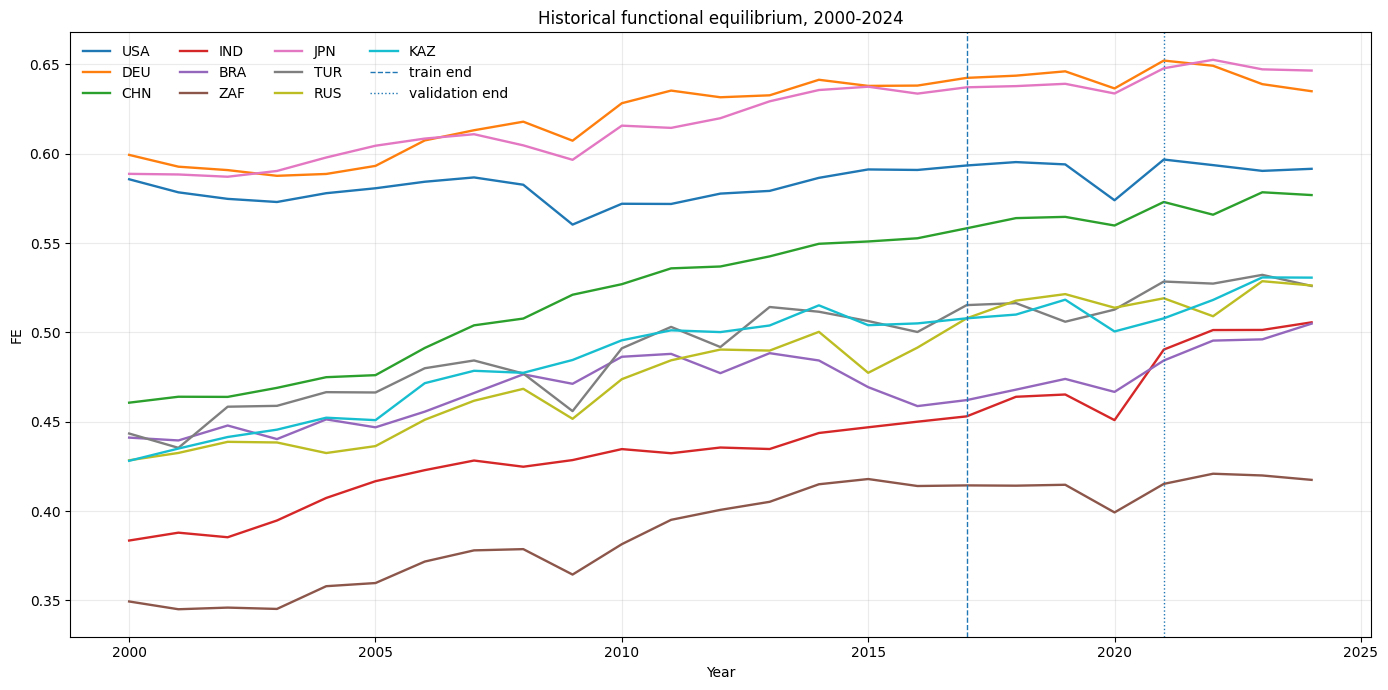

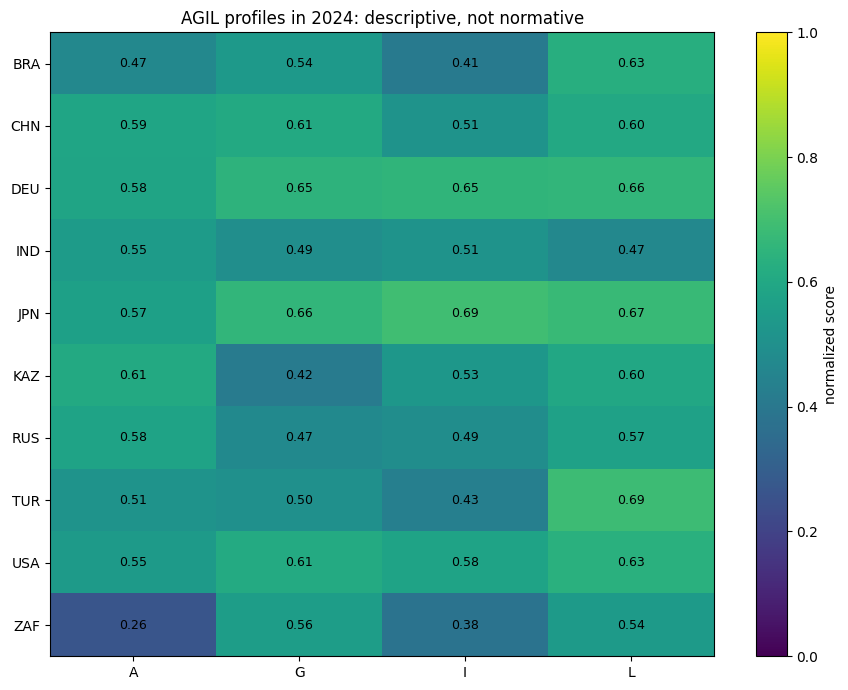

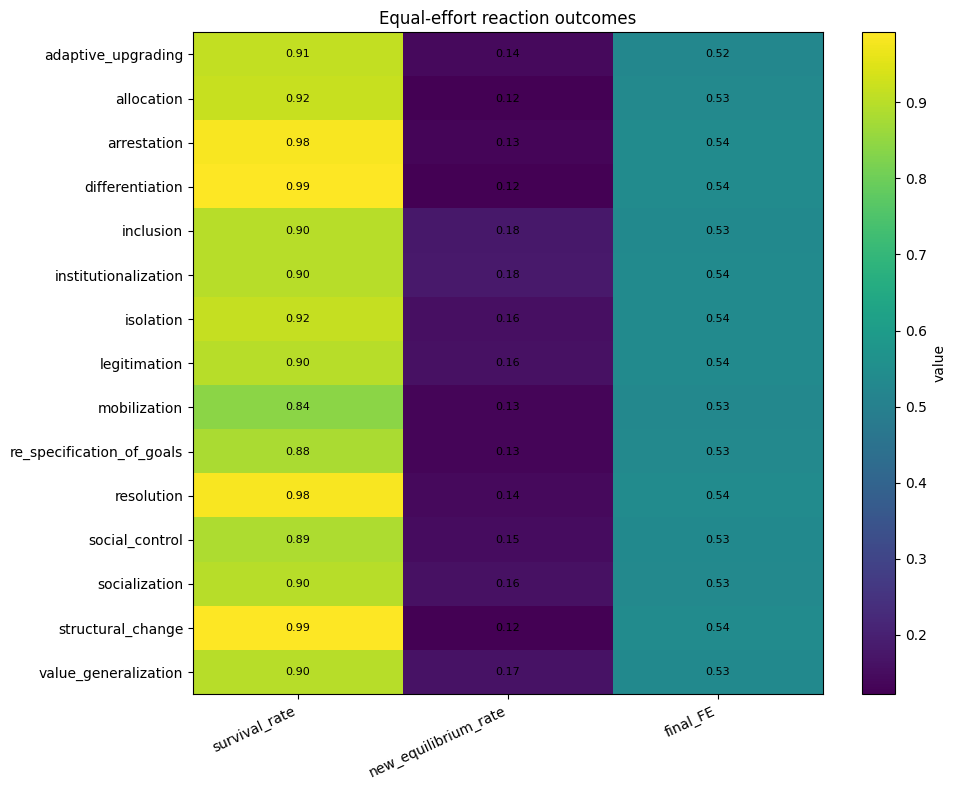

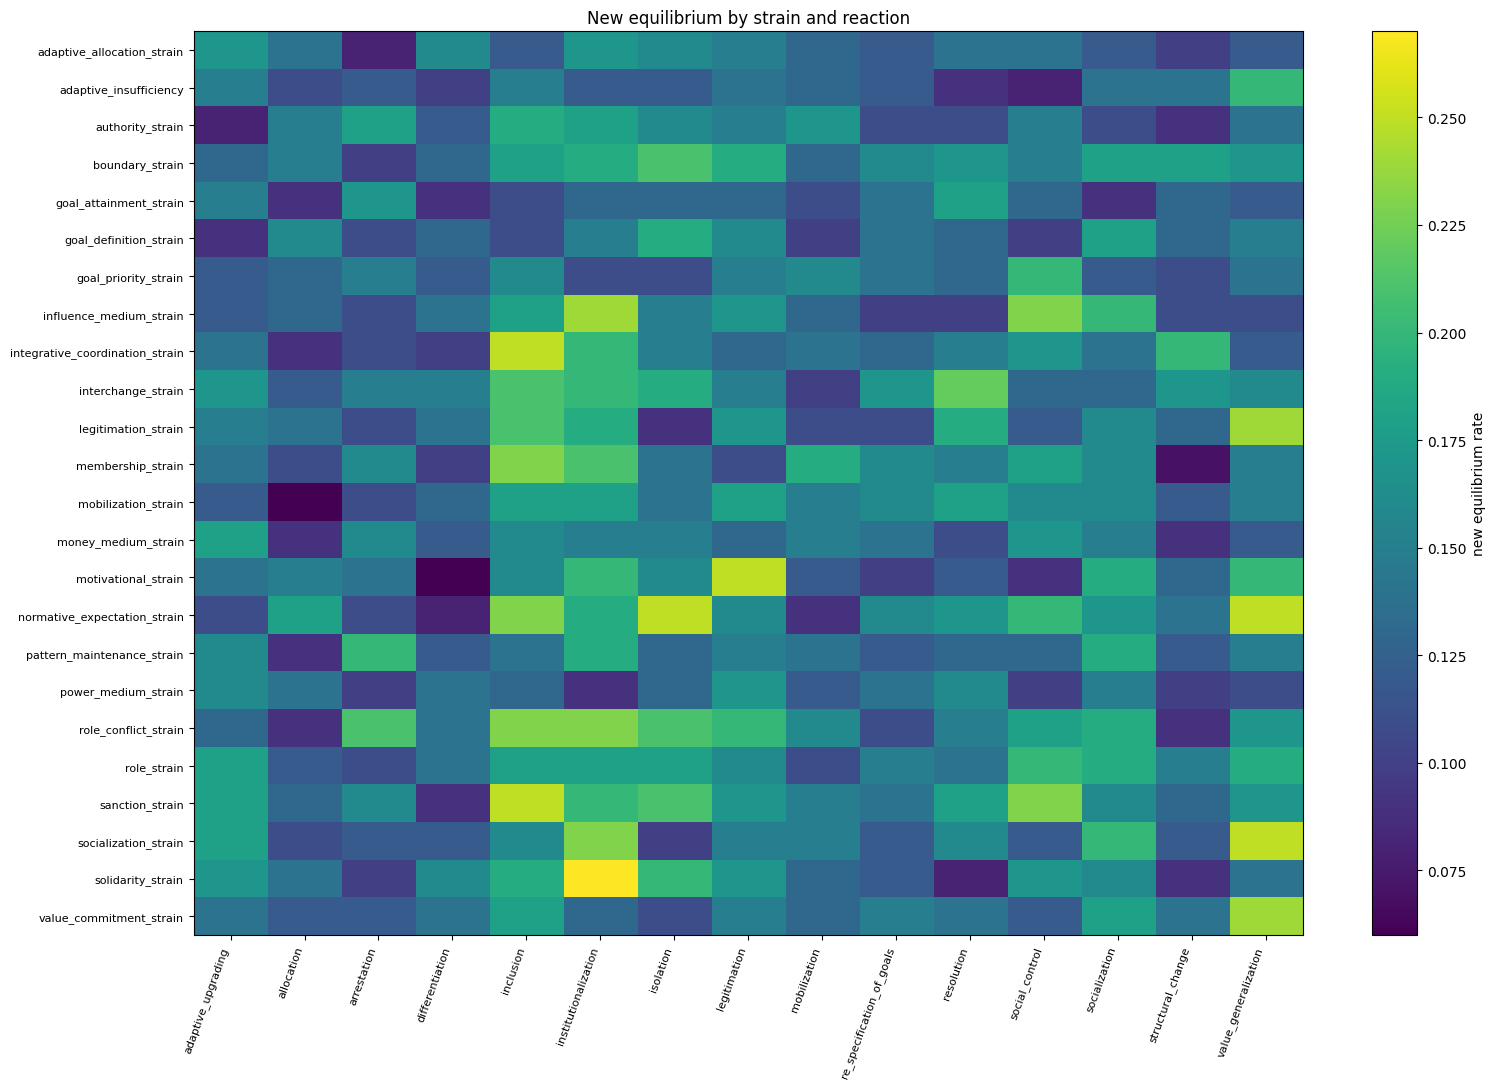

In [17]:
#@title 11.1. Графики PNG/SVG и таблицы-источники
FIGURE_DATA={}
def save_figure(name,data):
    FIGURE_DATA[name]=data.copy(); plt.tight_layout()
    plt.savefig(OUT/'figures_png'/f'{name}.png',dpi=300,bbox_inches='tight')
    plt.savefig(OUT/'figures_svg'/f'{name}.svg',bbox_inches='tight')
    plt.show(); plt.close()

hist=state[['country','year','FE']].copy()
fig,ax=plt.subplots(figsize=(14,7))
for country in CFG.countries:
    g=hist[hist.country==country]; ax.plot(g.year,g.FE,label=country,linewidth=1.7)
ax.axvline(CFG.train_end,ls='--',lw=1,label='train end'); ax.axvline(CFG.validation_end,ls=':',lw=1,label='validation end')
ax.set(title='Historical functional equilibrium, 2000-2024',xlabel='Year',ylabel='FE'); ax.grid(alpha=.25); ax.legend(ncol=4,frameon=False)
save_figure('01_historical_FE',hist)

profile=state[state.year==CFG.end_year][['country','A','G','I','L','Reliability']].set_index('country')
fig,ax=plt.subplots(figsize=(9,7)); im=ax.imshow(profile[list(AGIL)].values,aspect='auto',vmin=0,vmax=1)
ax.set_xticks(range(4),AGIL); ax.set_yticks(range(len(profile)),profile.index)
for i in range(profile.shape[0]):
    for j in range(4): ax.text(j,i,f'{profile.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9)
fig.colorbar(im,ax=ax,label='normalized score'); ax.set_title('AGIL profiles in 2024: descriptive, not normative')
save_figure('02_AGIL_profiles_2024',profile.reset_index())

rp=reaction_results[['reaction','survival_rate','new_equilibrium_rate','final_FE']].set_index('reaction')
fig,ax=plt.subplots(figsize=(10,8)); im=ax.imshow(rp.values,aspect='auto'); ax.set_xticks(range(rp.shape[1]),rp.columns,rotation=25,ha='right'); ax.set_yticks(range(rp.shape[0]),rp.index)
for i in range(rp.shape[0]):
    for j in range(rp.shape[1]): ax.text(j,i,f'{rp.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,label='value'); ax.set_title('Equal-effort reaction outcomes')
save_figure('03_reaction_outcomes',rp.reset_index())

sr=simulation_summary.groupby(['scenario','reaction']).new_equilibrium.mean().unstack()
fig,ax=plt.subplots(figsize=(16,11)); im=ax.imshow(sr.values,aspect='auto'); ax.set_xticks(range(len(sr.columns)),sr.columns,rotation=70,ha='right',fontsize=8); ax.set_yticks(range(len(sr.index)),sr.index,fontsize=8); fig.colorbar(im,ax=ax,label='new equilibrium rate'); ax.set_title('New equilibrium by strain and reaction')
save_figure('04_strain_reaction_equilibrium',sr.reset_index())

advance('графики сохранены')

In [18]:
#@title 12.1. Excel, CSV.GZ, manifest и ZIP
def add_readme(writer,title,description,sheets):
    wb=writer.book; ws=wb.add_worksheet('README'); writer.sheets['README']=ws
    title_fmt=wb.add_format({'bold':True,'font_size':16,'font_color':'white','bg_color':'#1F4E78'})
    head=wb.add_format({'bold':True,'font_color':'white','bg_color':'#5B9BD5'}); wrap=wb.add_format({'text_wrap':True,'valign':'top'}); link=wb.add_format({'font_color':'blue','underline':1})
    ws.set_column('A:A',32); ws.set_column('B:B',92); ws.merge_range('A1:B1',title,title_fmt); ws.write('A3','Назначение',head); ws.write('B3',description,wrap); ws.write('A5','Лист',head); ws.write('B5','Содержание',head)
    for r,(name,desc) in enumerate(sheets,start=5): ws.write_url(r,0,f"internal:'{name}'!A1",link,string=name); ws.write(r,1,desc,wrap)
    ws.freeze_panes(5,0)

def format_book(writer):
    wb=writer.book; head=wb.add_format({'bold':True,'font_color':'white','bg_color':'#4472C4','border':1,'text_wrap':True,'align':'center','valign':'vcenter'})
    for name,ws in writer.sheets.items():
        if name=='README': continue
        ws.freeze_panes(1,0); ws.set_row(0,30,head); ws.set_column(0,min(3,ws.dim_colmax),19)
        if ws.dim_colmax>3: ws.set_column(4,ws.dim_colmax,16)
        if ws.dim_rowmax>0 and ws.dim_colmax>=0: ws.autofilter(0,0,ws.dim_rowmax,ws.dim_colmax)

csv_exports={'raw_2000_2024':raw,'processed_panel':panel,'historical_state':state,'validation':validation,'simulation_summary':simulation_summary,'trajectories_full':trajectories,'trajectory_aggregates':trajectory_aggregates,'pairwise_tests':pairwise_table}
for name,table in csv_exports.items(): table.to_csv(OUT/'tables_csv'/f'{name}.csv.gz',index=False,compression='gzip')

with pd.ExcelWriter(OUT/'00_Parsons_Master_Index.xlsx',engine='xlsxwriter') as writer:
    pd.DataFrame([{'parameter':k,'value':str(v)} for k,v in asdict(CFG).items()]).to_excel(writer,sheet_name='Configuration',index=False)
    pd.DataFrame([{'construct':'Functional equilibrium','formula':'FE=(A*G*I*L)^(1/4)'},{'construct':'Bottleneck','formula':'B=min(A,G,I,L)'},{'construct':'Coverage','formula':'C_i=observed/(countries*years)'},{'construct':'Alignment','formula':'Align=(a_r dot -q_k)/(norms)'}]).to_excel(writer,sheet_name='Formulas',index=False)
    data_quality.to_excel(writer,sheet_name='Data_Quality',index=False)
    add_readme(writer,'Parsons V2.1 - Master index','Навигация и паспорт эксперимента.',[('Configuration','Фиксированные параметры.'),('Formulas','Основные формулы.'),('Data_Quality','Аудит входных данных.')]); format_book(writer)

with pd.ExcelWriter(OUT/'01_Parsons_Data_and_Measurement.xlsx',engine='xlsxwriter') as writer:
    raw.to_excel(writer,sheet_name='Raw_2000_2024',index=False); coverage.to_excel(writer,sheet_name='Indicator_Coverage',index=False); coverage[~coverage.included].to_excel(writer,sheet_name='Excluded_Indicators',index=False); train_parameters.to_excel(writer,sheet_name='Train_Parameters',index=False); imputation_audit.to_excel(writer,sheet_name='Imputation_Audit',index=False); panel.to_excel(writer,sheet_name='Processed_Long',index=False); agil_long.to_excel(writer,sheet_name='AGIL_Long',index=False); state.to_excel(writer,sheet_name='AGIL_Wide',index=False); measurement_diagnostics.to_excel(writer,sheet_name='Measurement_Diagnostics',index=False)
    add_readme(writer,'Parsons V2.1 - Data and measurement','Данные, покрытие, train-only обработка и AGIL.',[('Raw_2000_2024','Исходная панель.'),('Indicator_Coverage','Покрытие и решения.'),('Excluded_Indicators','Показатели ниже 70 процентов.'),('Train_Parameters','Медианы и IQR train.'),('Imputation_Audit','Аудит заполнения.'),('Processed_Long','Обработанная панель.'),('AGIL_Long','AGIL в длинном виде.'),('AGIL_Wide','Состояния страны-года.'),('Measurement_Diagnostics','Диагностика измерения.')]); format_book(writer)

with pd.ExcelWriter(OUT/'02_Parsons_Historical_and_Simulation.xlsx',engine='xlsxwriter') as writer:
    state.to_excel(writer,sheet_name='Historical_States',index=False); validation.to_excel(writer,sheet_name='Historical_Validation',index=False); transition_parameters.to_excel(writer,sheet_name='Transition_Parameters',index=False); thresholds.to_excel(writer,sheet_name='Thresholds',index=False); scenario_catalog.to_excel(writer,sheet_name='Strain_Catalog',index=False); reaction_catalog.to_excel(writer,sheet_name='Reaction_Catalog',index=False); simulation_summary.to_excel(writer,sheet_name='Seed_Results',index=False); trajectory_aggregates.to_excel(writer,sheet_name='Trajectory_Aggregates',index=False)
    add_readme(writer,'Parsons V2.1 - Historical and simulation','Историческая модель и сценарные результаты.',[('Historical_States','Исторические состояния.'),('Historical_Validation','OOS-проверка.'),('Transition_Parameters','Параметры перехода.'),('Thresholds','Train-only пороги.'),('Strain_Catalog','24 strain.'),('Reaction_Catalog','15 реакций.'),('Seed_Results','Результаты сидов.'),('Trajectory_Aggregates','Средние траектории.')]); format_book(writer)

with pd.ExcelWriter(OUT/'03_Parsons_Statistics_and_Figures.xlsx',engine='xlsxwriter') as writer:
    friedman_table.to_excel(writer,sheet_name='Friedman',index=False); pairwise_table.to_excel(writer,sheet_name='Wilcoxon_BH',index=False); reaction_results.to_excel(writer,sheet_name='Reaction_Results',index=False); country_results.to_excel(writer,sheet_name='Country_Results',index=False); strain_results.to_excel(writer,sheet_name='Strain_Results',index=False)
    fig_sheets=[]
    for i,(name,table) in enumerate(FIGURE_DATA.items(),1):
        sheet=f'Fig{i:02d}_{name[:21]}'; table.to_excel(writer,sheet_name=sheet,index=False); fig_sheets.append((sheet,f'Данные рисунка {name}.'))
    add_readme(writer,'Parsons V2.1 - Statistics and figures','Статистика и точные данные рисунков.',[('Friedman','Общие сравнения.'),('Wilcoxon_BH','Парные тесты.'),('Reaction_Results','Итоги реакций.'),('Country_Results','Описательные итоги стран.'),('Strain_Results','Итоги strain.'),*fig_sheets]); format_book(writer)

readme=(
    f'# Parsons Political System Experiment V2.1\n\n'
    f'Data mode: real_only\n'
    f'Synthetic fallback: false\n'
    f'Window: {CFG.start_year}-{CFG.end_year}\n'
    f'Coverage threshold: {CFG.coverage_threshold:.0%}\n'
    f'Included indicators: {len(included_codes)}\n'
    f'Excluded indicators: {len(excluded_codes)}\n'
    f'Seeds: {CFG.n_seeds}\n'
)
(OUT/'README.md').write_text(readme,encoding='utf-8')
manifest={'experiment':'Parsons Political System Computational Experiment','version':'2.1-real-clean','data_mode':'real_only','synthetic_fallback':False,'config':asdict(CFG),'ontology_hash':ONTOLOGY_HASH,'data_file':DATA_PATH.name,'data_sha256':DATA_HASH,'included_indicators':included_codes,'excluded_indicators':excluded_codes,'pipeline_log':PIPELINE_LOG,'files':[]}
for p in sorted(OUT.rglob('*')):
    if p.is_file(): manifest['files'].append({'path':str(p.relative_to(OUT)),'bytes':p.stat().st_size,'sha256':hashlib.sha256(p.read_bytes()).hexdigest()})
(OUT/'manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding='utf-8')
archive_path=shutil.make_archive(str(OUT.parent/'Parsons_Experiment_V2_1_REAL_outputs'),'zip',root_dir=OUT)
advance('Excel, manifest и ZIP')
GLOBAL_PROGRESS.close()
print('Готово:',archive_path)

Готово: /content/Parsons_Experiment_V2_1_REAL_outputs.zip


In [19]:
#@title 12.2. Скачивание архива в Colab
archive_file=Path(archive_path)
print(f'Размер архива: {archive_file.stat().st_size/1024**2:.2f} MB')
try:
    from google.colab import files
    files.download(str(archive_file))
except ImportError:
    print('Файл:',archive_file.resolve())

Размер архива: 64.25 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Ограничение интерпретации

Результаты описывают вычислительно реконструированные функциональные конфигурации. Они не являются нормативным рейтингом стран и не отождествляют международный индикатор с самой функцией Парсонса.